In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import glob
import os
path = r"C:\Users\hp\Downloads\project"
all_files = glob.glob(os.path.join(path, "*.xlsx"))
dfs = []
for file in all_files:
    df = pd.read_excel(file, skiprows=1, header=None)
    df = df.iloc[:, :4]
    df = df.dropna(how='all')
    df = df[1:]  # skip the first row which has column names
    dfs.append(df)

upi = pd.concat(dfs, ignore_index=True)
upi.columns = ['Month', 'Banks', 'Volume_Mn', 'Value_Cr']

print(upi.shape)
print(upi.head(10))


(78, 4)
            Month  Banks Volume_Mn     Value_Cr
0   February-2020    146   1325.69  2,22,516.95
1    January-2020    144   1305.02  2,16,242.97
2   December-2019    143    1308.4  2,02,520.76
3   November-2019    143   1218.77  1,89,229.09
4    October-2019    141   1148.36  1,91,359.94
5  September-2019    141    955.02  1,61,456.56
6     August-2019    141    918.35  1,54,504.89
7       July-2019    143    822.29  1,46,386.64
8       June-2019    142    754.54  1,46,566.35
9        May-2019    143    733.54  1,52,449.29


In [3]:
upi['Month'] = pd.to_datetime(upi['Month'], format='%B-%Y')
upi = upi.sort_values('Month').reset_index(drop=True)
print(upi['Month'].head())
upi['Value_Cr'] = upi['Value_Cr'].astype(str).str.replace(',','').str.strip().astype(float)
upi['Volume_Mn'] = upi['Volume_Mn'].astype(str).str.replace(',','').str.strip().astype(float)
print(upi.dtypes)  
print(upi.isnull().sum())
print(upi.shape)
print(upi.describe()) 

0   2019-04-01
1   2019-05-01
2   2019-06-01
3   2019-07-01
4   2019-08-01
Name: Month, dtype: datetime64[us]
Month        datetime64[us]
Banks                 int64
Volume_Mn           float64
Value_Cr            float64
dtype: object
Month        0
Banks        0
Volume_Mn    0
Value_Cr     0
dtype: int64
(78, 4)
                            Month       Banks    Volume_Mn      Value_Cr
count                          78   78.000000     78.00000  7.800000e+01
mean   2022-09-17 13:13:50.769230  394.487179   8629.17141  1.262326e+06
min           2019-04-01 00:00:00  141.000000    733.54000  1.420344e+05
25%           2020-12-08 18:00:00  207.000000   2248.84500  4.183978e+05
50%           2022-09-16 00:00:00  361.500000   7043.11000  1.153516e+06
75%           2024-06-23 12:00:00  604.250000  14335.62250  2.056786e+06
max           2026-04-01 00:00:00  713.000000  22346.80000  2.902988e+06
std                           NaN  202.410265   6867.94232  8.809379e+05


In [4]:
upi['avg_transaction_value'] = (upi['Value_Cr'] * 1e7) / (upi['Volume_Mn'] * 1e6)
print(upi['avg_transaction_value'].describe())
print(upi['avg_transaction_value'].head())

count      78.000000
mean     1613.383711
std       212.718886
min      1242.220312
25%      1433.876709
50%      1629.658488
75%      1800.851673
max      2078.268261
Name: avg_transaction_value, dtype: float64
0    1816.784431
1    2078.268261
2    1942.459644
3    1780.231305
4    1682.418359
Name: avg_transaction_value, dtype: float64


# UPI Transaction Behaviour Analysis
### 78 months of official NPCI data — April 2019 to 2026
---

### Growth
**How big was UPI's growth and how fast did it take off?**

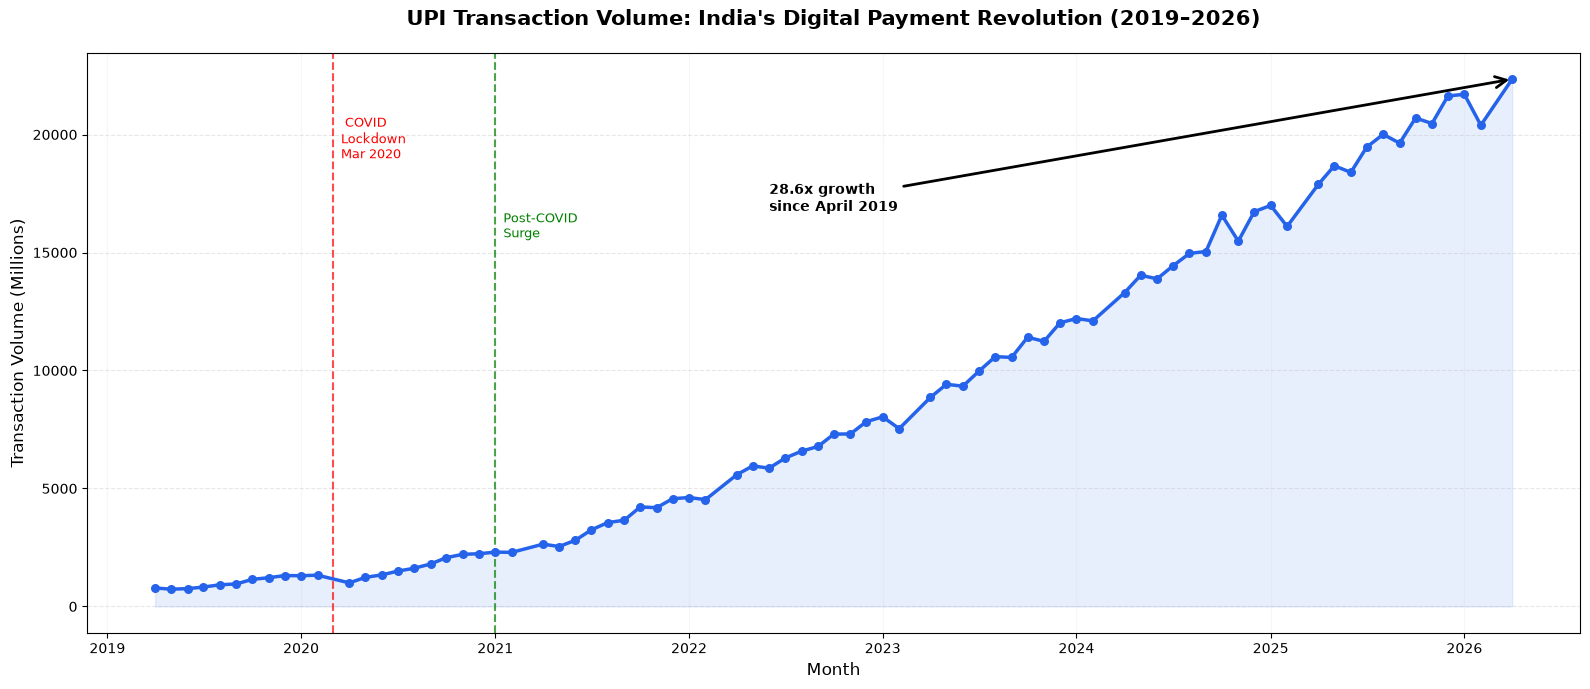

April 2019 Volume: 781.79 Million transactions
Latest Month Volume: 22,346.80 Million transactions
Total Growth: 28.6x in 5 years


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(upi['Month'], upi['Volume_Mn'], color='#2563EB', linewidth=2.5, zorder=3)
ax.fill_between(upi['Month'], upi['Volume_Mn'], alpha=0.1, color='#2563EB')
ax.scatter(upi['Month'], upi['Volume_Mn'], color='#2563EB', s=30, zorder=4)

# COVID annotation
ax.axvline(x=pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(pd.Timestamp('2020-03-01'), upi['Volume_Mn'].max() * 0.85,'   COVID\n  Lockdown\n  Mar 2020',  color='red', fontsize=9)

# Post COVID surge annotation
ax.axvline(x=pd.Timestamp('2021-01-01'), color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(pd.Timestamp('2021-01-01'), upi['Volume_Mn'].max() * 0.7,'  Post-COVID\n  Surge', color='green', fontsize=9)

# Growth multiple annotation
first_val = upi['Volume_Mn'].iloc[0]
last_val = upi['Volume_Mn'].iloc[-1]
growth = round(last_val / first_val, 1)

ax.annotate(f'{growth}x growth\nsince April 2019', xy=(upi['Month'].iloc[-1], last_val),  xytext=(pd.Timestamp('2022-06-01'), last_val * 0.75),
            arrowprops=dict(arrowstyle='->', color='black',linewidth=2,mutation_scale=20), fontsize=10, fontweight='bold')

ax.set_title('UPI Transaction Volume: India\'s Digital Payment Revolution (2019–2026)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Transaction Volume (Millions)', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.grid(axis='x', alpha=0.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_upi_volume_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the headline numbers below the chart
print(f"April 2019 Volume: {first_val:,.2f} Million transactions")
print(f"Latest Month Volume: {last_val:,.2f} Million transactions")
print(f"Total Growth: {growth}x in 5 years")


UPI grew **28.6x in 5 years** 
781 million transactions in April 2019 to 22,346 million in May 2026.

The curve has two distinct phases. 
Before 2021, growth was gradual as UPI was primarily urban, used by smartphone owners for rent, bills, and peer transfers. 
The monthly average transaction value peaked at ₹2,078, reflecting a higher-income early adopter base.

Post 2021, the growth went vertical and the four reasons that drove this :
- Cheap 4G smartphones reached tier 2 and tier 3 cities
- PhonePe, Google Pay, and Paytm competed aggressively with cashbacks
- Small merchants adopted QR codes at scale (example, tea stalls, autos, vegetable vendors)
- Government's zero MDR policy removed transaction fees entirely
  
The March 2020 lockdown caused exactly one month of decline and by June 2020 volume had recovered.

---

**Does transaction value tell a different story than volume ?**

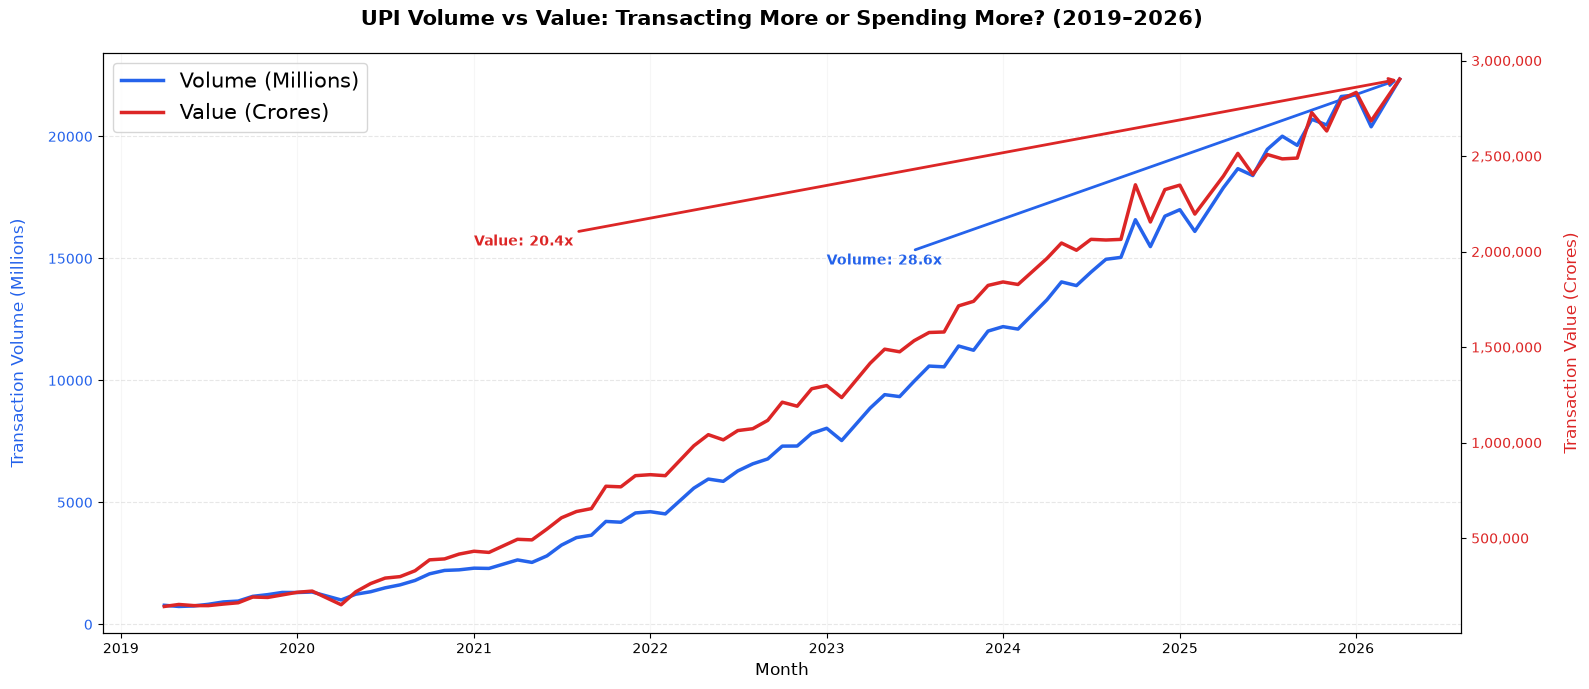

Volume Growth: 28.6x
Value Growth: 20.4x
Value grew slower than Volume


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.plot(upi['Month'], upi['Volume_Mn'], color='#2563EB', linewidth=2.5, zorder=3, label='Volume (Millions)')

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Transaction Volume (Millions)', fontsize=12, color='#2563EB', labelpad=15)
ax1.tick_params(axis='y', labelcolor='#2563EB')

ax2 = ax1.twinx()
ax2.plot(upi['Month'], upi['Value_Cr'], color='#DC2626', linewidth=2.5, zorder=3, label='Value (Crores)')
ax2.set_ylabel('Transaction Value (Crores)', fontsize=12, color='#DC2626', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax2.yaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
vol_growth = round(upi['Volume_Mn'].iloc[-1] / upi['Volume_Mn'].iloc[0], 1)
val_growth = round(upi['Value_Cr'].iloc[-1] / upi['Value_Cr'].iloc[0], 1)

ax1.annotate(f'Volume: {vol_growth}x',  xy=(upi['Month'].iloc[-1], upi['Volume_Mn'].iloc[-1]), xytext=(pd.Timestamp('2023-01-01'), 
             upi['Volume_Mn'].max() * 0.66), arrowprops=dict(arrowstyle='->', color='#2563EB', lw=2), fontsize=10, fontweight='bold', color='#2563EB')
ax2.annotate(f'Value: {val_growth}x', xy=(upi['Month'].iloc[-1], upi['Value_Cr'].iloc[-1]), xytext=(pd.Timestamp('2021-01-01'),
             upi['Value_Cr'].max() * 0.7), arrowprops=dict(arrowstyle='->', color='#DC2626', lw=2), fontsize=10, fontweight='bold', color='#DC2626')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=15)

ax1.set_title('UPI Volume vs Value: Transacting More or Spending More? (2019–2026)', fontsize=15, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.grid(axis='x', alpha=0.1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart2_volume_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Volume Growth: {vol_growth}x")
print(f"Value Growth: {val_growth}x")
if val_growth > vol_growth :
    print("Value grew faster than Volume")
else:
    print("Value grew slower than Volume")
    







Volume grew **28.6x**. Value grew only **20.4x**
The gap here tells that every year the average UPI transaction got smaller.
In 2019, UPI was mainly used by urban professionals for transferring rents, splitting bills etc.
By 2026, it spread among vendors, auto drivers, local shops for smaller payments.
The data didnt just scale rather it democratized.

---

**Which year was the real inflection point?**

In [7]:
upi['Year'] = upi['Month'].dt.year
yearly = upi.groupby('Year').agg(Total_Volume=('Volume_Mn', 'sum'),Total_Value=('Value_Cr', 'sum')).reset_index()


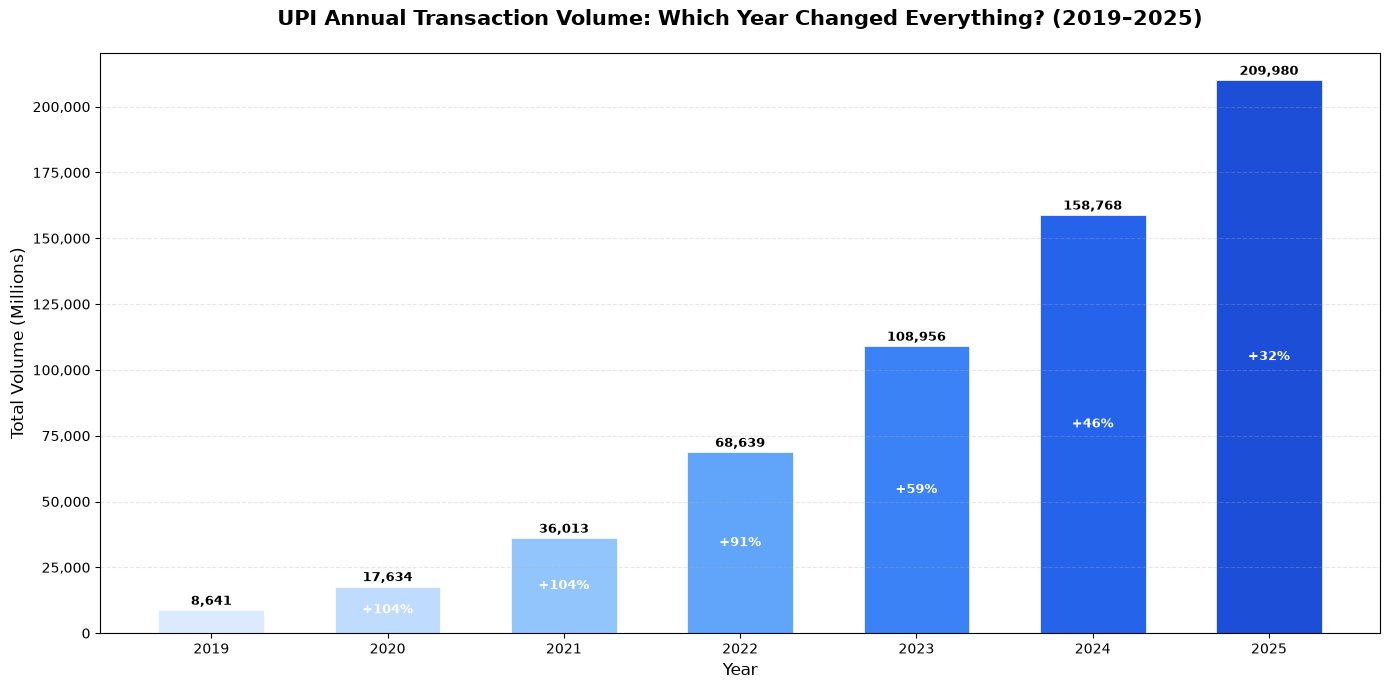

In [8]:
yearly_full = yearly[yearly['Year'] < 2026]  # removing the incomplete year 2026

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(yearly_full['Year'], yearly_full['Total_Volume'], color=['#DBEAFE','#BFDBFE','#93C5FD', '#60A5FA','#3B82F6','#2563EB','#1D4ED8'],
              width=0.6, edgecolor='white', linewidth=0.5)

# Adding the value labels on top of bars
for bar, val in zip(bars, yearly_full['Total_Volume']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# annotating growth
for i in range(1, len(yearly_full)):
    growth = round((yearly_full['Total_Volume'].iloc[i] /  yearly_full['Total_Volume'].iloc[i-1] - 1) * 100)
    ax.text(yearly_full['Year'].iloc[i], yearly_full['Total_Volume'].iloc[i] / 2, f'+{growth}%',  
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('UPI Annual Transaction Volume: Which Year Changed Everything? (2019–2025)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Volume (Millions)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')) #converts 200000 to 200,000
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(yearly_full['Year'])
plt.tight_layout()
plt.savefig('chart3_yearly_volume.png', dpi=150, bbox_inches='tight')
plt.show()


**2021 was the inflection point**
As the transactions doubled two years in a row (+104% in 2021, +91% in 2022).
Growth is now moderating , +32% in 2025.This shows that UPI is transitioning from hypergrowth to infrastructure.

---

### Behaviour
**As UPI scaled, did the average transaction value get bigger or smaller?**

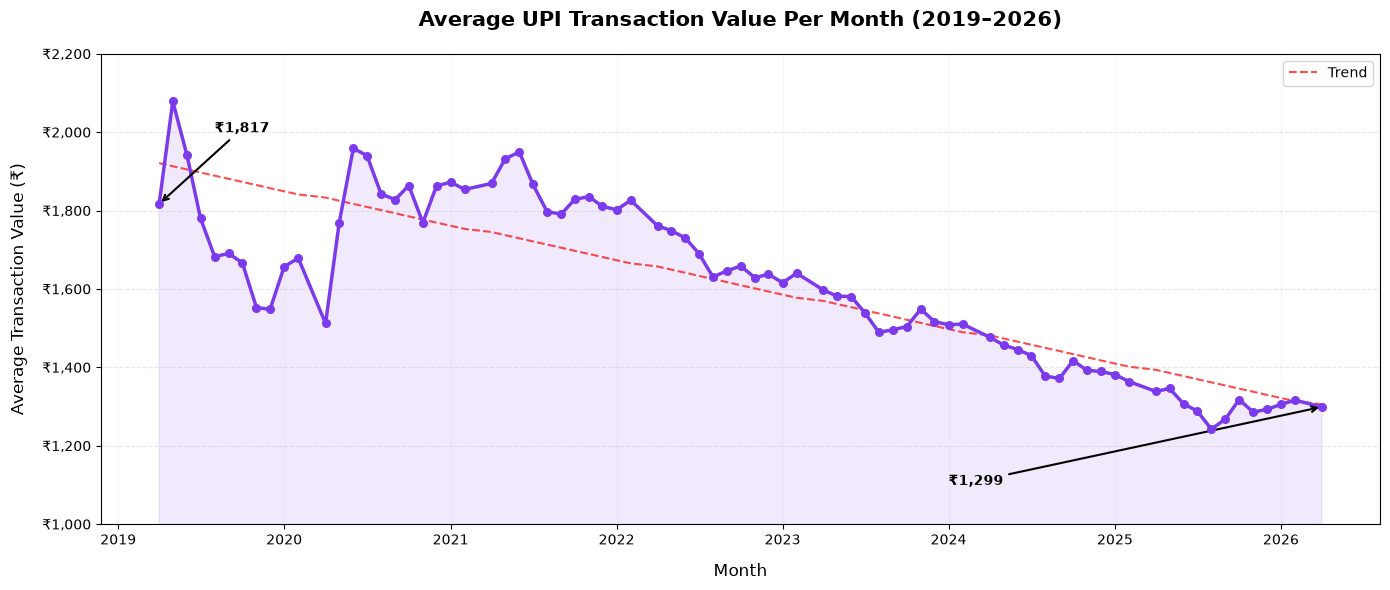

April 2019 avg: ₹1,817
Latest month avg: ₹1,299
Total decline: 28.5%


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(upi['Month'], upi['avg_transaction_value'], color='#7C3AED', linewidth=2.5, zorder=3)
ax.fill_between(upi['Month'], upi['avg_transaction_value'], alpha=0.1, color='#7C3AED')
ax.scatter(upi['Month'], upi['avg_transaction_value'], color='#7C3AED', s=30, zorder=4)

# Adding a trend line
import numpy as np
z = np.polyfit(range(len(upi)), upi['avg_transaction_value'], 1)
p = np.poly1d(z)
ax.plot(upi['Month'], p(range(len(upi))),color='red', linewidth=1.5, linestyle='--', alpha=0.7,  label='Trend')

# Annotating first and last value
ax.annotate(f"₹{upi['avg_transaction_value'].iloc[0]:,.0f}", xy=(upi['Month'].iloc[0], upi['avg_transaction_value'].iloc[0]),
            xytext=(pd.Timestamp('2019-08-01'), 2000), arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, fontweight='bold')

ax.annotate(f"₹{upi['avg_transaction_value'].iloc[-1]:,.0f}", xy=(upi['Month'].iloc[-1], upi['avg_transaction_value'].iloc[-1]),
            xytext=(pd.Timestamp('2024-01-01'), 1100), arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, fontweight='bold')

ax.legend(fontsize=10)
ax.set_title('Average UPI Transaction Value Per Month (2019–2026)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12,labelpad=11)
ax.set_ylabel('Average Transaction Value (₹)', fontsize=12,labelpad=11)
ax.yaxis.set_major_formatter( mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.grid(axis='x', alpha=0.1)
ax.set_ylim(1000,2200)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_avg_transaction_value.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"April 2019 avg: ₹{upi['avg_transaction_value'].iloc[0]:,.0f}")
print(f"Latest month avg: ₹{upi['avg_transaction_value'].iloc[-1]:,.0f}")
decline = round((1 - upi['avg_transaction_value'].iloc[-1] /  upi['avg_transaction_value'].iloc[0]) * 100, 1)
print(f"Total decline: {decline}%")




The average UPI transaction fell from **₹1,817 in 2019** 
to **₹1,299 in 2026** --> a decline of **28.5%**.

While total volume grew 28.6x, the individual payment got smaller every year, this shows that more Indians joined UPI, 
but for progressively smaller transactions. This indicates not just more users, a fundamentally different kind of user.

---

**Does UPI have a seasonal pattern or does it grow uniformly?** 

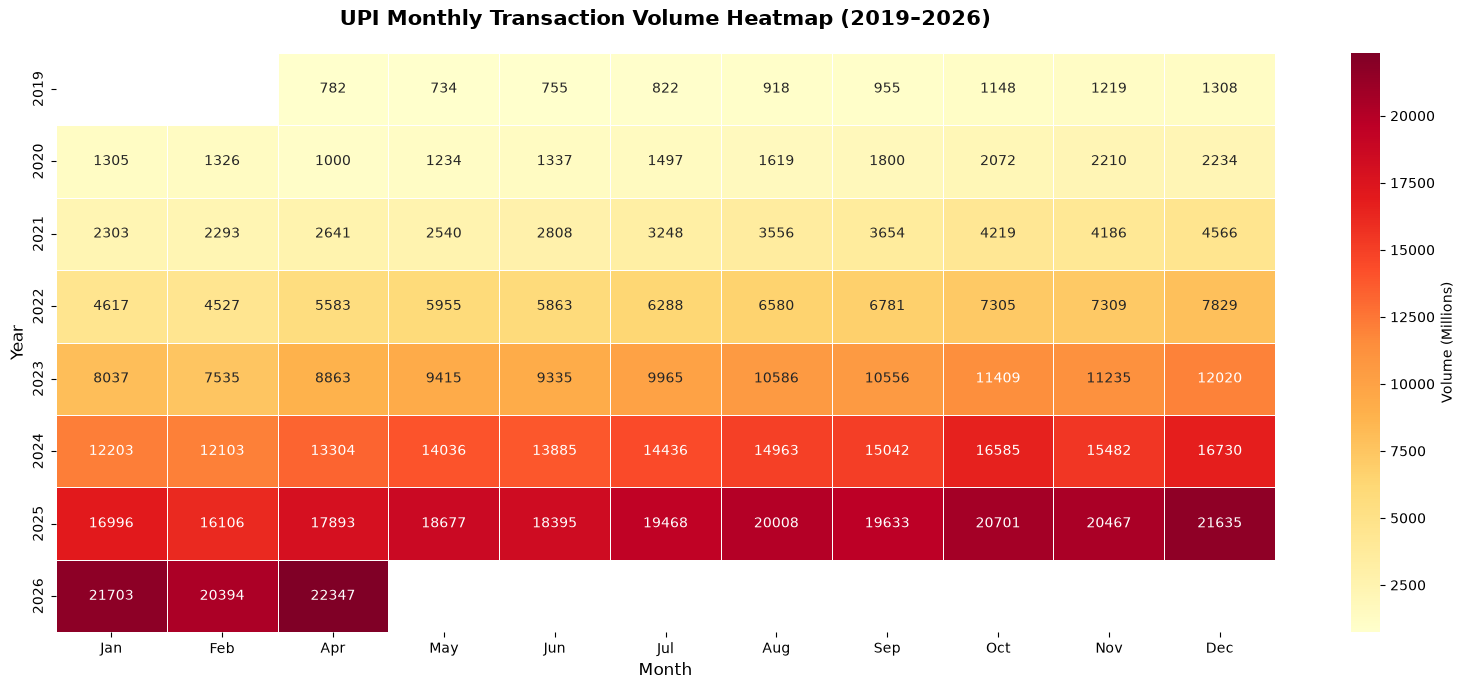

In [10]:
import seaborn as sns
upi['MonthNum'] = upi['Month'].dt.month
upi['MonthName'] = upi['Month'].dt.strftime('%b')
upi['Year'] = upi['Month'].dt.year

pivot = upi.pivot_table(values='Volume_Mn', index='Year', columns='MonthName', aggfunc='sum')
pivot = pivot[['Jan','Feb','Apr','May','Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']] #other months not present in data
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Volume (Millions)'})

ax.set_title('UPI Monthly Transaction Volume Heatmap (2019–2026)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

This shows how year on year growth dominates as each row is uniformly darker than the one above it.

But within every year, October to December consistently outperforms as the festival season leaves a measurable 
footprint in the data without any exception.

---

### Insights
This UPI transaction data is a type of economic inclusion.
The headlines say UPI processed 18 billion transactions in a month but what the data tell us is that 
those 18 billion transactions are worth less per transaction than the 780 million transactions of April 2019.

Five findings from this analysis:
- **28.6x** growth in transaction volume over 5 years
- **20.4x** growth in transaction value i.e. slower than volume
- **2021** was the real inflection point i.e. two consecutive years of ~100% growth
- **28.5%** decline in average transaction value, from ₹1,817 to ₹1,299
- Festival months (Oct-Nov) consistently outperform every single year
---
### Limitations

This data only captures digital transactions. 
Cash payments are invisible here which dominate lower income segments.
True average Indian transaction values are significantly lower than what this dataset shows.

---
### Data
Official NPCI monthly statistics --> npci.org.in
April 2019 to May 2026 - 78 months.